# NB10 — Physiological grounding and PulsePhysio bridge (revised)
NB10 is conditional. It distinguishes two modes that must never be conflated:
Literature benchmark mode: propagates prespecified haemodynamic changes (for sensitivity analysis). This is not PulsePhysio output.
External simulator mode: consumes a real PulsePhysio export produced by a documented simulator run.
The original notebook only subtracted 3.5 mmHg and called the result validation. That is a useful sensitivity benchmark, but it is not physiological simulation and cannot validate PulsePhysio. This revision preserves provenance in every output row.
Because the clinical and lifestyle datasets contain different, non-overlapping patients, their per-patient risk deltas cannot be paired. Agreement is therefore evaluated within the clinical cohort: benchmark haemodynamics versus genuine exported haemodynamics, propagated through the same locked clinical model.

In [1]:
import os
import shutil
from google.colab import drive

# 1. Remove the interfering local folder
if os.path.exists('/content/drive'):
    shutil.rmtree('/content/drive')

# 2. Mount properly
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from __future__ import annotations

import hashlib
import json
import os
import pickle
import platform
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.special import expit

RANDOM_STATE = 42
N_BOOT = 2000
BASE_DIR = Path(os.environ.get("CAD_DT_BASE_DIR", "/content/drive/MyDrive/CAD_DT_Final"))

CLINICAL_TEST = BASE_DIR / "Outputs/Clinical/df_clinical_test.csv"
CLINICAL_TEST_RAW = BASE_DIR / "Outputs/Clinical/df_clinical_test_raw.csv"
CLINICAL_SCALER = BASE_DIR / "Outputs/Clinical/clinical_scaler.pkl"
CLINICAL_MODEL = BASE_DIR / "Outputs/Models/clinical_pipeline.pkl"
PRS_VECTOR = BASE_DIR / "Outputs/Genetics/prs_feature_vector.pkl"

# Optional real simulator export. Required columns are validated below.
PULSEPHYSIO_EXPORT = Path(os.environ.get(
    "PULSEPHYSIO_EXPORT",
    str(BASE_DIR / "Outputs/Pulse/pulsephysio_export.csv")
))
PULSE_DIR = BASE_DIR / "Outputs/Pulse"
FIG_DIR = BASE_DIR / "Outputs/Figures"
PULSE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="paper")
required = [CLINICAL_TEST, CLINICAL_TEST_RAW, CLINICAL_SCALER, CLINICAL_MODEL, PRS_VECTOR]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required artifacts:\n- " + "\n- ".join(missing))

In [3]:
def load_pickle(path):
    with Path(path).open("rb") as f:
        return pickle.load(f)


def model_features(model):
    sets = []
    for fitted in model.calibrated_classifiers_:
        estimator = getattr(fitted, "estimator", None) or getattr(fitted, "base_estimator", None)
        sets.append(tuple(map(str, estimator.named_steps["scaler"].feature_names_in_)))
    if not sets or len(set(sets)) != 1:
        raise ValueError("Unable to establish one authoritative clinical feature schema.")
    return list(sets[0])


clinical = pd.read_csv(CLINICAL_TEST)
raw = pd.read_csv(CLINICAL_TEST_RAW)
model = load_pickle(CLINICAL_MODEL)
clinical_preprocessor_scaler = load_pickle(CLINICAL_SCALER)
prs = load_pickle(PRS_VECTOR)
features = model_features(model)

if len(clinical) != len(raw):
    raise ValueError("Processed and raw clinical test files differ in row count; positional alignment is unsafe.")
if not set(features).issubset(clinical.columns):
    raise ValueError(f"Processed test set lacks model features: {sorted(set(features)-set(clinical.columns))}")

clinical = clinical.reset_index(drop=True)
raw = raw.reset_index(drop=True)
clinical.insert(0, "patient_id", np.arange(len(clinical)))
raw.insert(0, "patient_id", np.arange(len(raw)))

# Preserve missingness flags; impute only simulator initialization values.
for col, fallback in {"resting_bp": 120.0, "cholesterol": 200.0, "max_heart_rate": 150.0}.items():
    raw[f"{col}_was_missing"] = raw[col].isna()
    median = raw[col].median()
    raw[col] = raw[col].fillna(median if np.isfinite(median) else fallback)

PRS_SIGMOID = float(expit(float(prs["prs_raw"])))
W_MODEL, W_PRS = .85, .15
CLINICAL_INPUT_IS_NB2_STANDARDIZED = (
    abs(float(clinical["age"].median())) < 10 and float(clinical["age"].std()) < 3
)
clinical_scale_index = {str(f): i for i, f in enumerate(clinical_preprocessor_scaler.feature_names_in_)}

def physical_to_model_input(feature, value):
    if not CLINICAL_INPUT_IS_NB2_STANDARDIZED or feature not in clinical_scale_index:
        return float(value)
    i = clinical_scale_index[feature]
    return float((value - clinical_preprocessor_scaler.mean_[i]) /
                 clinical_preprocessor_scaler.scale_[i])

def predict(row):
    X = pd.DataFrame([[row[f] for f in features]], columns=features)
    p_model = float(model.predict_proba(X)[0, 1])
    return p_model, float(np.clip(W_MODEL*p_model + W_PRS*PRS_SIGMOID, 0, 1))

print(f"Clinical cohort n={len(clinical)}, features={features}")
print("Clinical input space:", "NB2-standardized" if CLINICAL_INPUT_IS_NB2_STANDARDIZED else "physical/raw")
print("Mode:", "external simulator export" if PULSEPHYSIO_EXPORT.exists() else "literature benchmark only")

Clinical cohort n=238, features=['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'max_heart_rate', 'oldpeak', 'resting_ecg_0.0', 'resting_ecg_1.0', 'resting_ecg_2.0']
Clinical input space: NB2-standardized
Mode: literature benchmark only


In [4]:
BENCHMARKS = {
    "exercise_aerobic": {"sbp_delta": -3.5, "hr_delta": 0.0, "source": "Cornelissen & Smart (2013) benchmark"},
    "weight_loss_5pct": {"sbp_delta": -4.0, "hr_delta": 0.0, "source": "prespecified literature benchmark"},
    "smoking_cessation": {"sbp_delta": -5.0, "hr_delta": 0.0, "source": "prespecified literature benchmark"},
}


def initialize_patient(patient_id):
    r = raw.loc[patient_id]
    sbp = float(r.resting_bp)
    dbp = .67 * sbp  # approximation mandated by context; recorded as estimated
    return {
        "patient_id": int(patient_id), "age": float(r.age), "sex": int(r.sex),
        "baseline_sbp": sbp, "estimated_baseline_dbp": dbp,
        "estimated_baseline_map": (sbp + 2*dbp)/3,
        "baseline_hr": float(r.max_heart_rate), "cholesterol": float(r.cholesterol),
        "dbp_is_estimated": True,
        "sbp_was_imputed": bool(r.resting_bp_was_missing),
        "hr_was_imputed": bool(r.max_heart_rate_was_missing),
    }


def benchmark_haemodynamics():
    rows = []
    for patient_id in range(len(raw)):
        patient = initialize_patient(patient_id)
        for scenario, spec in BENCHMARKS.items():
            rows.append({**patient, "scenario": scenario,
                         "new_sbp": patient["baseline_sbp"] + spec["sbp_delta"],
                         "sbp_delta": spec["sbp_delta"],
                         "new_hr": patient["baseline_hr"] + spec["hr_delta"],
                         "hr_delta": spec["hr_delta"],
                         "provenance": "literature_benchmark", "source": spec["source"]})
    return pd.DataFrame(rows)


benchmark_hemo = benchmark_haemodynamics()

# Genuine simulator exports must provide outputs, not merely scenario labels.
EXPORT_COLS = {"patient_id", "scenario", "new_sbp", "new_hr", "simulator_name", "simulator_version"}
if PULSEPHYSIO_EXPORT.exists():
    simulator_hemo = pd.read_csv(PULSEPHYSIO_EXPORT)
    missing = EXPORT_COLS - set(simulator_hemo.columns)
    if missing:
        raise ValueError(f"PulsePhysio export is missing required provenance/output columns: {sorted(missing)}")
    if simulator_hemo.duplicated(["patient_id", "scenario"]).any():
        raise ValueError("PulsePhysio export has duplicate patient/scenario rows.")
    if not simulator_hemo.patient_id.between(0, len(raw)-1).all():
        raise ValueError("PulsePhysio export contains unknown patient_id values.")
    baseline = raw[["patient_id", "resting_bp", "max_heart_rate"]].rename(
        columns={"resting_bp": "baseline_sbp", "max_heart_rate": "baseline_hr"})
    simulator_hemo = simulator_hemo.merge(baseline, on="patient_id", validate="many_to_one")
    simulator_hemo["sbp_delta"] = simulator_hemo.new_sbp - simulator_hemo.baseline_sbp
    simulator_hemo["hr_delta"] = simulator_hemo.new_hr - simulator_hemo.baseline_hr
    simulator_hemo["provenance"] = "external_simulator_export"
else:
    simulator_hemo = pd.DataFrame()
    warnings.warn("No PulsePhysio export found. Results will be benchmark sensitivity analysis only—not Pulse validation.")

hemo_out = pd.concat([benchmark_hemo, simulator_hemo], ignore_index=True, sort=False)
hemo_out.to_csv(PULSE_DIR / "pulse_haemodynamic_deltas.csv", index=False)
display(hemo_out.head())

/tmp/ipykernel_528/849226124.py:58: UserWarning: No PulsePhysio export found. Results will be benchmark sensitivity analysis only—not Pulse validation.
  warnings.warn("No PulsePhysio export found. Results will be benchmark sensitivity analysis only—not Pulse validation.")


,patient_id,age,sex,baseline_sbp,estimated_baseline_dbp,estimated_baseline_map,baseline_hr,cholesterol,dbp_is_estimated,sbp_was_imputed,hr_was_imputed,scenario,new_sbp,sbp_delta,new_hr,hr_delta,provenance,source
0,0,57.0,1,140.0,93.8,109.2,120.0,237.0,True,False,False,exercise_aerobic,136.5,-3.5,120.0,0.0,literature_benchmark,Cornelissen & Smart (2013) benchmark
1,0,57.0,1,140.0,93.8,109.2,120.0,237.0,True,False,False,weight_loss_5pct,136.0,-4.0,120.0,0.0,literature_benchmark,prespecified literature benchmark
2,0,57.0,1,140.0,93.8,109.2,120.0,237.0,True,False,False,smoking_cessation,135.0,-5.0,120.0,0.0,literature_benchmark,prespecified literature benchmark
3,1,57.0,1,150.0,100.5,117.0,173.0,126.0,True,False,False,exercise_aerobic,146.5,-3.5,173.0,0.0,literature_benchmark,Cornelissen & Smart (2013) benchmark
4,1,57.0,1,150.0,100.5,117.0,173.0,126.0,True,False,False,weight_loss_5pct,146.0,-4.0,173.0,0.0,literature_benchmark,prespecified literature benchmark


In [5]:
def propagate(hemo: pd.DataFrame) -> pd.DataFrame:
    records = []
    for rec in hemo.itertuples(index=False):
        patient_id = int(rec.patient_id)
        base_row = clinical.loc[patient_id].copy()
        modified = base_row.copy()
        if "resting_bp" in features:
            modified["resting_bp"] = physical_to_model_input("resting_bp", rec.new_sbp)
        if "max_heart_rate" in features and np.isfinite(float(rec.new_hr)):
            modified["max_heart_rate"] = physical_to_model_input("max_heart_rate", rec.new_hr)
        p0_model, p0 = predict(base_row)
        p1_model, p1 = predict(modified)
        records.append({
            "patient_id": patient_id, "scenario": rec.scenario, "provenance": rec.provenance,
            "baseline_risk": p0, "updated_risk": p1,
            "risk_delta": p0-p1, "relative_risk_delta_pct": 100*(p0-p1)/p0 if p0 > 0 else np.nan,
            "baseline_sbp": float(rec.baseline_sbp), "new_sbp": float(rec.new_sbp),
            "sbp_delta": float(rec.sbp_delta), "baseline_hr": float(rec.baseline_hr),
            "new_hr": float(rec.new_hr), "hr_delta": float(rec.hr_delta),
        })
    return pd.DataFrame(records)


risk_scores = propagate(hemo_out)

# Compare like with like only when genuine simulator rows exist.
if len(simulator_hemo):
    bench = risk_scores[risk_scores.provenance == "literature_benchmark"].rename(
        columns={"risk_delta": "benchmark_risk_delta", "sbp_delta": "benchmark_sbp_delta"})
    sim = risk_scores[risk_scores.provenance == "external_simulator_export"].rename(
        columns={"risk_delta": "pulse_grounded_risk_delta", "sbp_delta": "pulse_sbp_delta"})
    agreement = sim.merge(bench[["patient_id", "scenario", "benchmark_risk_delta", "benchmark_sbp_delta"]],
                          on=["patient_id", "scenario"], how="left", validate="one_to_one")
    agreement["ml_only_risk_delta"] = agreement["benchmark_risk_delta"]
    denom = agreement.benchmark_risk_delta.abs().clip(lower=1e-12)
    agreement["relative_disagreement_pct"] = 100*(agreement.pulse_grounded_risk_delta-agreement.benchmark_risk_delta).abs()/denom
    agreement["agreement_within_5pct"] = agreement.relative_disagreement_pct <= 5
else:
    agreement = risk_scores.copy()
    agreement["benchmark_risk_delta"] = agreement.risk_delta
    agreement["ml_only_risk_delta"] = agreement.risk_delta
    agreement["pulse_grounded_risk_delta"] = np.nan
    agreement["relative_disagreement_pct"] = np.nan
    agreement["agreement_within_5pct"] = pd.NA

agreement.to_csv(PULSE_DIR / "pulse_updated_risk_scores.csv", index=False)
display(agreement.head())

,patient_id,scenario,provenance,baseline_risk,updated_risk,risk_delta,relative_risk_delta_pct,baseline_sbp,new_sbp,sbp_delta,baseline_hr,new_hr,hr_delta,benchmark_risk_delta,ml_only_risk_delta,pulse_grounded_risk_delta,relative_disagreement_pct,agreement_within_5pct
0,0,exercise_aerobic,literature_benchmark,0.921763,0.921887,-0.000124,-0.013426,140.0,136.5,-3.5,120.0,120.0,0.0,-0.000124,-0.000124,NaN,NaN,<NA>
1,0,weight_loss_5pct,literature_benchmark,0.921763,0.921887,-0.000124,-0.013426,140.0,136.0,-4.0,120.0,120.0,0.0,-0.000124,-0.000124,NaN,NaN,<NA>
2,0,smoking_cessation,literature_benchmark,0.921763,0.921887,-0.000124,-0.013426,140.0,135.0,-5.0,120.0,120.0,0.0,-0.000124,-0.000124,NaN,NaN,<NA>
3,1,exercise_aerobic,literature_benchmark,0.271764,0.291789,-0.020025,-7.368400,150.0,146.5,-3.5,173.0,173.0,0.0,-0.020025,-0.020025,NaN,NaN,<NA>
4,1,weight_loss_5pct,literature_benchmark,0.271764,0.291789,-0.020025,-7.368400,150.0,146.0,-4.0,173.0,173.0,0.0,-0.020025,-0.020025,NaN,NaN,<NA>


,provenance,scenario,n,mean_sbp_delta,mean_risk_delta,risk_delta_ci_low,risk_delta_ci_high,pct_positive_risk_delta
0,literature_benchmark,exercise_aerobic,238,-3.5,-0.013691,-0.022788,-0.004025,43.277311
1,literature_benchmark,smoking_cessation,238,-5.0,-0.016842,-0.027265,-0.006094,42.016807
2,literature_benchmark,weight_loss_5pct,238,-4.0,-0.013691,-0.022788,-0.004025,43.277311


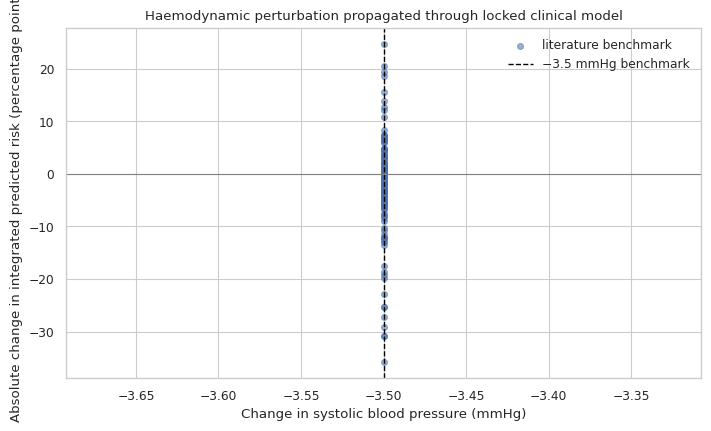

In [6]:
def bootstrap_mean_ci(x, n_boot=N_BOOT):
    x = pd.Series(x).dropna().to_numpy(float)
    if len(x) < 2: return np.nan, np.nan
    rng = np.random.default_rng(RANDOM_STATE)
    means = [rng.choice(x, len(x), replace=True).mean() for _ in range(n_boot)]
    return tuple(np.quantile(means, [.025, .975]))


summary = []
for (provenance, scenario), g in risk_scores.groupby(["provenance", "scenario"]):
    lo, hi = bootstrap_mean_ci(g.risk_delta)
    summary.append({"provenance": provenance, "scenario": scenario, "n": len(g),
                    "mean_sbp_delta": g.sbp_delta.mean(), "mean_risk_delta": g.risk_delta.mean(),
                    "risk_delta_ci_low": lo, "risk_delta_ci_high": hi,
                    "pct_positive_risk_delta": 100*(g.risk_delta > 0).mean()})
summary = pd.DataFrame(summary)
summary.to_csv(PULSE_DIR / "pulse_summary_with_bootstrap_ci.csv", index=False)
display(summary)

fig, ax = plt.subplots(figsize=(7.2, 4.4))
exercise = risk_scores[risk_scores.scenario == "exercise_aerobic"]
for provenance, g in exercise.groupby("provenance"):
    ax.scatter(g.sbp_delta, 100*g.risk_delta, s=18, alpha=.55, label=provenance.replace("_", " "))
ax.axvline(-3.5, color="black", ls="--", lw=1, label="−3.5 mmHg benchmark")
ax.axhline(0, color="grey", lw=.8)
ax.set(xlabel="Change in systolic blood pressure (mmHg)",
       ylabel="Absolute change in integrated predicted risk (percentage points)",
       title="Haemodynamic perturbation propagated through locked clinical model")
ax.legend(frameon=False)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"pulse_vs_ml_delta_comparison.{ext}", bbox_inches="tight", dpi=300)
plt.show()

In [7]:
def sha256(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

manifest = {
    "analysis": "NB10 physiological grounding bridge",
    "mode": "external_simulator_export" if PULSEPHYSIO_EXPORT.exists() else "literature_benchmark_only",
    "pulsephysio_claim_permitted": bool(PULSEPHYSIO_EXPORT.exists()),
    "random_state": RANDOM_STATE,
    "n_bootstrap": N_BOOT,
    "python": sys.version,
    "platform": platform.platform(),
    "inputs_sha256": {str(p.relative_to(BASE_DIR)): sha256(p) for p in required},
    "external_export": str(PULSEPHYSIO_EXPORT) if PULSEPHYSIO_EXPORT.exists() else None,
    "clinical_features": features,
    "limitations": [
        "Diastolic BP is estimated as 0.67 × systolic BP for initialization only.",
        "The model response is associational, not a causal treatment effect.",
        "Benchmark mode is not PulsePhysio simulation or validation.",
        "Lifestyle and clinical cohorts have no patient-level overlap.",
    ],
}
(PULSE_DIR / "nb10_run_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print("Saved NB10 outputs to", PULSE_DIR)
if not PULSEPHYSIO_EXPORT.exists():
    print("IMPORTANT: Do not describe these results as PulsePhysio-derived. Provide a real simulator export first.")


Saved NB10 outputs to /content/drive/MyDrive/CAD_DT_Final/Outputs/Pulse
IMPORTANT: Do not describe these results as PulsePhysio-derived. Provide a real simulator export first.
